## Variational Autoencoder (VAE) on MNIST Dataset

This notebook will demonstrate how to implement and train a Variational Autoencoder (VAE) on the MNIST dataset using TensorFlow and Keras. We will then use the trained VAE to generate new digits and reconstruct existing ones.

### 1. Setup and Data Preprocessing

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 784)
x_test shape: (10000, 784)


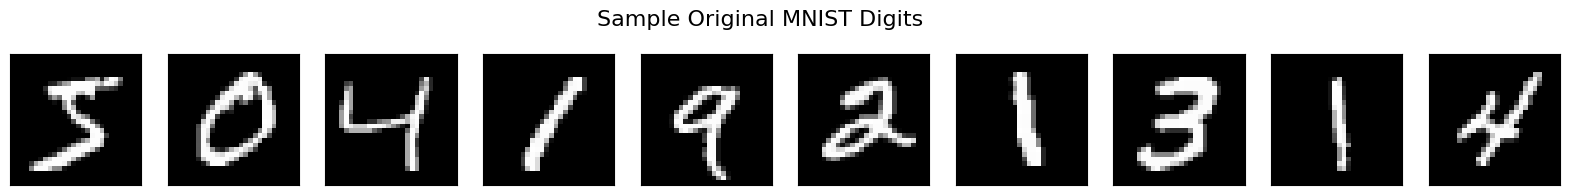

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize and reshape the data
# Each image is 28x28 pixels. We flatten it to 784-dimensional vector.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

# Display a few original images for verification
def plot_digits(images, title="Original Digits"):
    n = 10 # Number of digits to display
    plt.figure(figsize=(20, 4))
    plt.suptitle(title, fontsize=16)
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

plot_digits(x_train, title="Sample Original MNIST Digits")

### 2. VAE Model Architecture

#### 2.1. Encoder

In [2]:
original_dim = 784 # 28*28 pixels
intermediate_dim = 256
latent_dim = 2 # 2-dimensional latent space for easy visualization

# Define the Encoder
encoder_inputs = keras.Input(shape=(original_dim,))
h = layers.Dense(intermediate_dim, activation='relu')(encoder_inputs)
z_mean = layers.Dense(latent_dim, name='z_mean')(h)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(h)

# Create a sampling layer for the latent space (Reparameterization Trick)
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.2. Decoder

In [3]:
# Define the Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
decoder_h = layers.Dense(intermediate_dim, activation='relu')(latent_inputs)
decoder_outputs = layers.Dense(original_dim, activation='sigmoid')(decoder_h)
decoder = keras.Model(latent_inputs, decoder_outputs, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.3. VAE Model

In [12]:
# Define the VAE as a Model with a custom train_step
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Manually calculate binary cross-entropy loss per pixel
            reconstruction_loss = -tf.reduce_sum(
                data * tf.math.log(reconstruction + keras.backend.epsilon()) +
                (1 - data) * tf.math.log(1 - reconstruction + keras.backend.epsilon()),
                axis=1
            )
            reconstruction_loss = tf.reduce_mean(reconstruction_loss)

            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

### 3. Train the VAE

In [13]:
batch_size = 64
epochs = 10

vae.fit(x_train, epochs=epochs, batch_size=batch_size)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - kl_loss: 7.0301 - loss: 190.7242 - reconstruction_loss: 183.6940
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 4.8230 - loss: 168.7919 - reconstruction_loss: 163.9688
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 4.9854 - loss: 165.5569 - reconstruction_loss: 160.5715
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 5.1145 - loss: 163.4704 - reconstruction_loss: 158.3559
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 5.2045 - loss: 161.9902 - reconstruction_loss: 156.7857
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 5.2841 - loss: 160.7720 - reconstruction_loss: 155.4878
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - kl_loss: 5.3492 - loss: 159.8076 - reconstruction_loss: 154.4583
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - kl_loss: 5.4255 - loss: 158.9428 - reconstruction_loss: 153.5173
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━

### 4. Visualize Latent Space and Generate Digits

#### 4.1. Visualize Latent Space

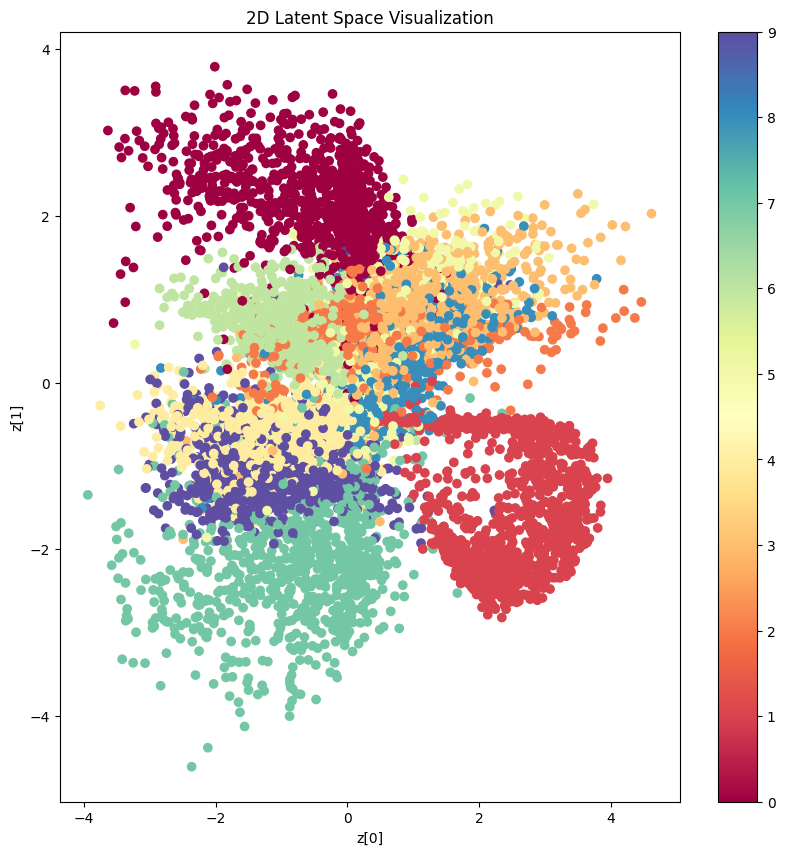

In [14]:
# Load the full MNIST dataset again to get labels for visualization
(_, y_train), (_, y_test) = keras.datasets.mnist.load_data()

def plot_latent_space(vae_model, data, labels):
    z_mean, _, _ = vae_model.encoder.predict(data, verbose=0)
    plt.figure(figsize=(10, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap='Spectral')
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("2D Latent Space Visualization")
    plt.show()

plot_latent_space(vae, x_test, y_test)

#### 4.2. Generate New Digits

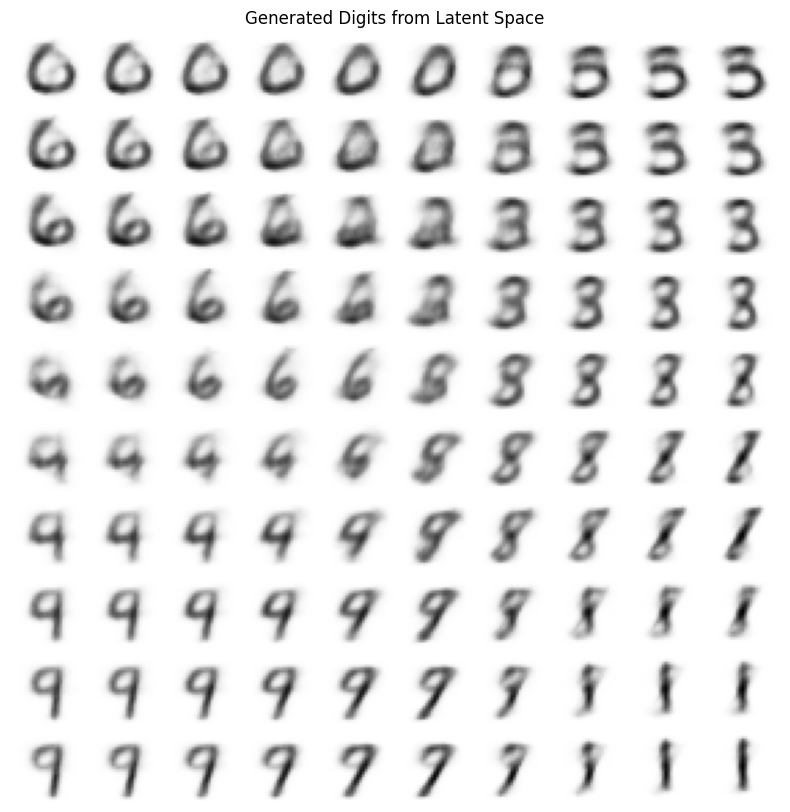

In [15]:
def plot_generated_digits(decoder_model, n=10):
    figure = np.zeros((28 * n, 28 * n))
    grid_x = np.linspace(-1.5, 1.5, n)
    grid_y = np.linspace(-1.5, 1.5, n)[::-1] # Reverse y to have 0 at bottom

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder_model.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(28, 28)
            figure[i * 28: (i + 1) * 28, j * 28: (j + 1) * 28] = digit

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='Greys')
    plt.axis('off')
    plt.title("Generated Digits from Latent Space")
    plt.show()

plot_generated_digits(decoder)


#### 4.3. Reconstruct Digits

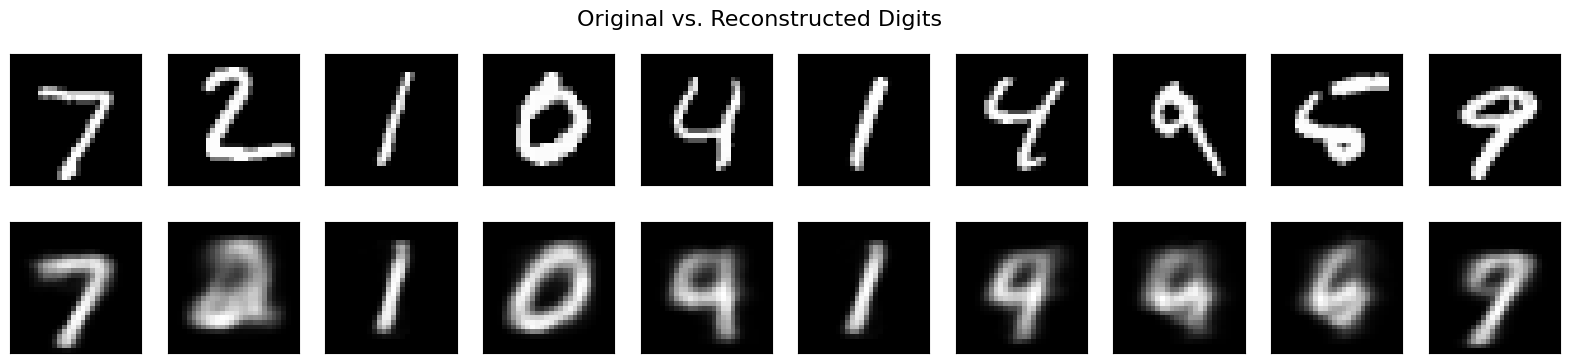

In [16]:
def plot_reconstructed_digits(vae_model, data, n=10):
    # Reconstruct digits
    _, _, z = vae_model.encoder.predict(data[:n], verbose=0)
    reconstructions = vae_model.decoder.predict(z, verbose=0)

    plt.figure(figsize=(20, 4))
    plt.suptitle("Original vs. Reconstructed Digits", fontsize=16)

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Reconstruction
        ax = plt.subplot(2, n, i + n + 1)
        plt.imshow(reconstructions[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

plot_reconstructed_digits(vae, x_test)

### 5. Conclusion

We have successfully implemented a Variational Autoencoder (VAE) on the MNIST dataset. We've seen how the VAE learns a compressed latent representation of the digits, which allows us to:

*   **Visualize the latent space:** Observe how similar digits cluster together.
*   **Generate new digits:** Sample from the latent space to create novel digit images.
*   **Reconstruct existing digits:** Demonstrate the VAE's ability to compress and decompress data while preserving essential features.

This concludes the VAE implementation on the MNIST dataset.